### ACLR Partition 10 — Training Trajectory Comparison

| Metric | SEED0 |  | SEED63 |  | SEED72 |  |
|---|---:|---:|---:|---:|---:|---:|
|  | mAP | mAP@50 | mAP | mAP@50 | mAP | mAP@50 |
| Train images | 361 |  | 349 |  | 326 |  |
| NC checkpoint | 1-class head |  | 80-class (0.491) |  | 80-class (0.472) |  |
| Epoch 0 (zero-shot) | 0.289 | 0.464 | 0.519 | 0.713 | 0.455 | 0.733 |
| Epoch 0 (post-train) | 0.303 | 0.498 | 0.258 | 0.371 | 0.281 | 0.421 |
| Δ epoch 0 | +0.014 | +0.034 | −0.261 | −0.342 | −0.174 | −0.312 |
| Epoch 1 | 0.311 | 0.510 | 0.266 | 0.381 | 0.286 | 0.421 |
| Epoch 2 | 0.325 | 0.525 | 0.272 | 0.390 | 0.292 | 0.430 |
| Best val/mAP | 0.453 (ep31) | 0.685 | 0.336 (ep33) | 0.462 | 0.341 (ep34) | 0.469 |
| Stopped at epoch | 81 |  | 41 |  | 47 |  |

### ACLR Partition 5 — Fixed NC Baseline 

1 — Forgetting is absent in SEED0, moderate in SEED72, severe in SEED63. Despite SEED63 and SEED72 sharing the same 80-class head approach, SEED63 loses -0.261 at epoch 0 vs SEED72's -0.174. This is directly explained by the zero-shot scores: SEED63 starts at 0.519 (more to lose), SEED72 at 0.455.

2 — SEED0 reaches 0.453, while SEED63/72 plateau around 0.336–0.341. The gap is ~0.11 mAP — substantial. As discussed, SEED0 never fell into the forgetting valley and climbed monotonically for 81 epochs.

3 — SEED63 and SEED72 converge to nearly the same plateau (0.336 vs 0.341) despite different NC checkpoints and zero-shot starting points. Once forgetting has occurred, both seeds seem to saturate at the same level — suggesting the WP training data (326–349 images) is the binding constraint, not the NC model quality.

4 — mAP@50 tells the same story — SEED0 reaches 0.685, SEED63/72 plateau around 0.462–0.469. The relative ordering and forgetting pattern are fully consistent across both metrics.

(NNN_NC_SEED10_augm_0422_2254)

| Metric | SEED0 |  | SEED72 |  |
|---|---:|---:|---:|---:|
|  | mAP | mAP@50 | mAP | mAP@50 |
| Train images | 178 |  | 171 |  |
| Val images | 517 |  | 533 |  |
| Test images | 384 |  | 333 |  |
| Epoch 0 (zero-shot) | 0.289 | 0.464 | 0.421 | 0.594 |
| Epoch 0 (post-train) | 0.306 | 0.498 | 0.295 | 0.445 |
| Δ epoch 0 | +0.017 | +0.034 | −0.126 | −0.149 |
| Epoch 1 | 0.308 | 0.502 | 0.296 | 0.445 |
| Epoch 2 | 0.318 | 0.517 | 0.298 | 0.445 |
| Best val/mAP | 0.429 (ep82) | 0.665 | 0.340 (ep32) | 0.495 |
| Stopped at epoch | 85 |  | 52 |  |


This also explains why ACLR's advantage disappears for SEED63 small partitions — 161 images is not enough to learn the coral/algae discriminative features regardless of how well those images are selected. The problem is not data selection quality, it is that the task is fundamentally harder and requires more examples of the specific background type to establish a reliable decision boundary.

In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
import fiftyone as fo

## list all dataset
print(fo.list_datasets())

# Close any zombie sessions that might be hanging
fo.close_app()

['FLPLAN', 'dugong', 'flplanpatches']


In [3]:
# load dataset
dataset = fo.load_dataset("flplanpatches")


In [4]:
session = fo.launch_app(dataset,
                        port=5151,
                        auto=False)

Session launched. Run `session.show()` to open the App in a cell output.


In [9]:
from fiftyone import ViewField as F

In [17]:
next(iter(dataset.match(
    F("filepath").contains_str("/share/home/e2406743/dataset/exported_img/new_dataset_flplan/images/FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_264__tile_0_2160_p.jpg")
).take(1)))

<SampleView: {
    'id': '6a16acc306514e31d6c3960b',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/exported_img/new_dataset_flplan/images/FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_264__tile_0_2160_p.jpg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 40693,
        'mime_type': 'image/jpeg',
        'width': 640,
        'height': 640,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 5, 27, 8, 35, 15, 707000),
    'last_modified_at': datetime.datetime(2026, 5, 27, 8, 35, 16, 679000),
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a16acc306514e31d6c39573',
                'attributes': {},
                'tags': [],
                'label': 'Dugong',
                'bounding_box': [0.8, 0.6109375, 0.2, 0.0890625],
                'mask': None,
                'mask_path': None,
                'confidence': None,
                'index': None,


In [ ]:
dataset.dataset.values("filepath")[3]

'/share/home/e2406743/dataset/exported_img/new_dataset_flplan/images/FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_264__tile_0_2160_p.jpg'

In [12]:
dataset.filter_fields("tile_name",
    F("tile_name")=="0_2160"
)

AttributeError: 'Dataset' object has no attribute 'filter_fields'

In [5]:

from pathlib import Path
import os
import numpy as np
import pandas as pd
import json
from fiftyone import ViewField as F
import matplotlib.pyplot as plt
import numpy as np


## renders plotly properly in a html instance. 
import plotly.io as pio
pio.renderers.default = "notebook"


Could not connect session, trying again in 10 seconds



In [18]:
from PIL import Image, ImageDraw

crop = Image.open("/share/home/e2406743/dataset/exported_img/new_dataset_flplan/images/FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_264__tile_0_2160_p.jpg")

draw = ImageDraw.Draw(crop)

# FiftyOne bbox is [top_left_x, top_left_y, w, h] normalised
bx, by, bw, bh = 0.8, 0.6109375, 0.2, 0.0890625
W, H = crop.size  # 640, 640

x1 = bx * W
y1 = by * H
x2 = (bx + bw) * W
y2 = (by + bh) * H

draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
crop.save("check_bbox_drawn.jpg")
print(f"Box drawn at: ({x1:.1f},{y1:.1f}) -> ({x2:.1f},{y2:.1f})")
print(f"Centre: ({(x1+x2)/2:.1f}, {(y1+y2)/2:.1f})")

Box drawn at: (512.0,391.0) -> (640.0,448.0)
Centre: (576.0, 419.5)


In [20]:
from PIL import Image, ImageDraw

src_path = "/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_26_03_09/images/FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_264.jpeg"
lbl_path = "/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_26_03_09/labels_yolo/FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_264.txt"

src = Image.open(src_path)
W, H = src.size
print(f"Source image: {W} x {H} px")

# Read YOLO label
with open(lbl_path) as f:
    line = f.read().strip()
print(f"Raw YOLO label: {line}")

parts = line.split()
cx_n, cy_n, bw_n, bh_n = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

# Convert to pixel coords
cx_px = cx_n * W;  cy_px = cy_n * H
bw_px = bw_n * W;  bh_px = bh_n * H

x1 = cx_px - bw_px/2;  y1 = cy_px - bh_px/2
x2 = cx_px + bw_px/2;  y2 = cy_px + bh_px/2

print(f"Centre px: ({cx_px:.1f}, {cy_px:.1f})")
print(f"Box px:    ({x1:.1f},{y1:.1f}) -> ({x2:.1f},{y2:.1f})")
print(f"Box size:  {x2-x1:.1f} x {y2-y1:.1f} px")

draw = ImageDraw.Draw(src)
draw.rectangle([x1, y1, x2, y2], outline="lime", width=4)

# Also draw the tile boundary
tile_x0, tile_y0 = 2160, 0
tile_x1_end, tile_y1_end = 2800, 640
draw.rectangle([tile_x0, tile_y0, tile_x1_end, tile_y1_end], outline="blue", width=3)

# Crop a tight view around the dugong + some context
pad = 150
view = src.crop((
    max(0, int(x1) - pad),
    max(0, int(y1) - pad),
    min(W, int(x2) + pad),
    min(H, int(y2) + pad),
))
view.save("check_source_annotation.jpg")
print(f"Saved: /tmp/check_source_annotation.jpg")
print(f"(lime=GT bbox, blue=tile boundary)")

Source image: 5280 x 3956 px
Raw YOLO label: 0 0.520170 0.106055 0.028220 0.014547
Centre px: (2746.5, 419.6)
Box px:    (2672.0,390.8) -> (2821.0,448.3)
Box size:  149.0 x 57.5 px
Saved: /tmp/check_source_annotation.jpg
(lime=GT bbox, blue=tile boundary)


Saved -> annotation_error_M4_M13.png


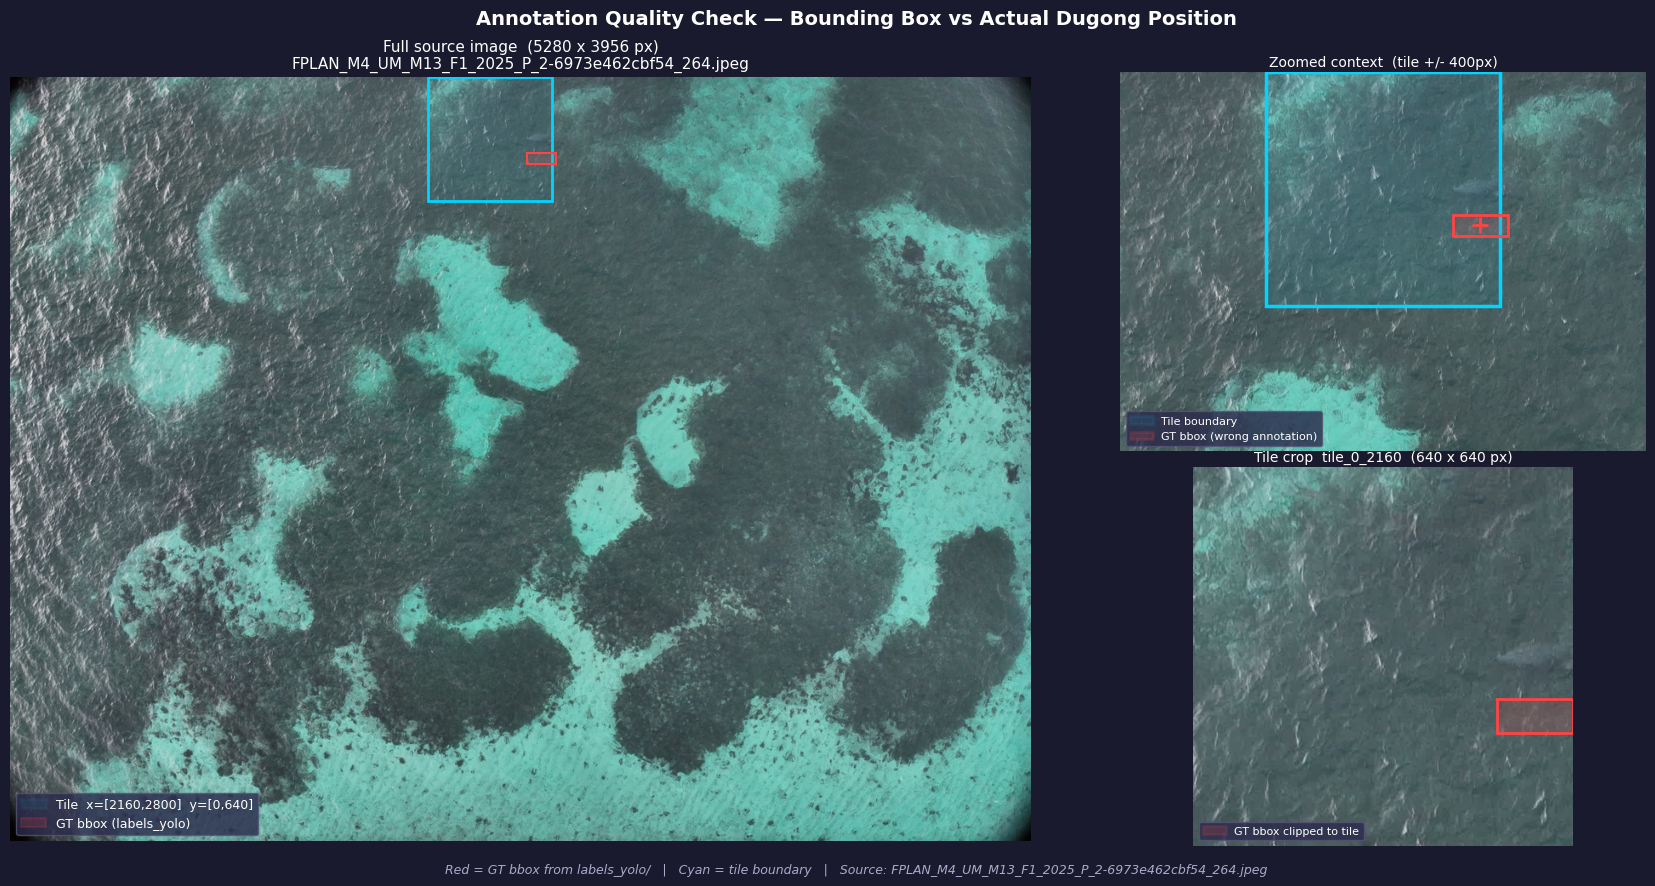

In [21]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import numpy as np


def plot_annotation_error(
    image_path,
    label_path,
    tile_x,
    tile_y,
    tile_size=640,
    context_pad=400,
    save_path=None,
    dpi=200,
):
    # ── load ──────────────────────────────────────────────────────────────────
    src = Image.open(image_path).convert("RGB")
    W, H = src.size

    boxes_px = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cx_px = float(parts[1]) * W;  cy_px = float(parts[2]) * H
            bw_px = float(parts[3]) * W;  bh_px = float(parts[4]) * H
            boxes_px.append((
                cx_px - bw_px / 2, cy_px - bh_px / 2,
                cx_px + bw_px / 2, cy_px + bh_px / 2,
            ))

    tile_x1, tile_y1 = tile_x, tile_y
    tile_x2 = min(tile_x + tile_size, W)
    tile_y2 = min(tile_y + tile_size, H)

    # ── crops ────────────────────────────────────────────────────────────────
    cx1 = max(0, tile_x1 - context_pad);  cy1 = max(0, tile_y1 - context_pad)
    cx2 = min(W, tile_x2 + context_pad);  cy2 = min(H, tile_y2 + context_pad)
    ctx_img  = np.array(src.crop((cx1, cy1, cx2, cy2)))
    tile_img = np.array(src.crop((tile_x1, tile_y1, tile_x2, tile_y2)))

    # downscale full image for display
    scale = min(1.0, 1200 / W)
    full_img = np.array(src.resize((int(W * scale), int(H * scale)), Image.LANCZOS))

    # ── colours ───────────────────────────────────────────────────────────────
    BG      = "#1a1a2e"
    CYAN    = "#00d4ff"
    RED     = "#ff4444"
    WHITE   = "#ffffff"
    MUTED   = "#aaaacc"

    # ── figure ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 9), facecolor=BG)
    gs  = fig.add_gridspec(
        2, 2,
        width_ratios=[1.6, 1], height_ratios=[1, 1],
        hspace=0.04, wspace=0.04,
        left=0.03, right=0.97, top=0.90, bottom=0.04,
    )
    ax_full    = fig.add_subplot(gs[:, 0])
    ax_context = fig.add_subplot(gs[0, 1])
    ax_tile    = fig.add_subplot(gs[1, 1])

    def _box(ax, x, y, w, h, color, alpha=0.12, lw=2, label=None):
        ax.add_patch(Rectangle((x, y), w, h,
                               linewidth=lw, edgecolor=color,
                               facecolor=color, alpha=alpha,
                               label=label))
        ax.add_patch(Rectangle((x, y), w, h,
                               linewidth=lw, edgecolor=color,
                               facecolor="none"))

    # ── Panel 1: full image ───────────────────────────────────────────────────
    ax_full.imshow(full_img)
    ax_full.set_facecolor(BG)

    _box(ax_full,
         tile_x1 * scale, tile_y1 * scale,
         (tile_x2 - tile_x1) * scale, (tile_y2 - tile_y1) * scale,
         CYAN, alpha=0.06, lw=2,
         label=f"Tile  x=[{tile_x1},{tile_x2}]  y=[{tile_y1},{tile_y2}]")

    for i, (bx1, by1, bx2, by2) in enumerate(boxes_px):
        _box(ax_full,
             bx1 * scale, by1 * scale,
             (bx2 - bx1) * scale, (by2 - by1) * scale,
             RED, alpha=0.15, lw=1.5,
             label="GT bbox (labels_yolo)" if i == 0 else "_")

    ax_full.set_title(
        f"Full source image  ({W} x {H} px)\n{Path(image_path).name}",
        color=WHITE, fontsize=11, pad=6)
    ax_full.legend(loc="lower left", fontsize=9,
                   facecolor="#2a2a4a", edgecolor="#555577", labelcolor=WHITE)
    ax_full.axis("off")

    # ── Panel 2: context ──────────────────────────────────────────────────────
    ax_context.imshow(ctx_img)
    ax_context.set_facecolor(BG)

    _box(ax_context,
         tile_x1 - cx1, tile_y1 - cy1,
         tile_x2 - tile_x1, tile_y2 - tile_y1,
         CYAN, alpha=0.08, lw=2.5,
         label="Tile boundary")

    for i, (bx1, by1, bx2, by2) in enumerate(boxes_px):
        _box(ax_context,
             bx1 - cx1, by1 - cy1,
             bx2 - bx1, by2 - by1,
             RED, alpha=0.15, lw=2,
             label="GT bbox (wrong annotation)" if i == 0 else "_")
        ax_context.plot(
            (bx1 + bx2) / 2 - cx1, (by1 + by2) / 2 - cy1,
            "+", color=RED, markersize=12, markeredgewidth=2)

    ax_context.set_title(
        f"Zoomed context  (tile +/- {context_pad}px)",
        color=WHITE, fontsize=10, pad=4)
    ax_context.legend(loc="lower left", fontsize=8,
                      facecolor="#2a2a4a", edgecolor="#555577", labelcolor=WHITE)
    ax_context.axis("off")

    # ── Panel 3: tile crop ────────────────────────────────────────────────────
    ax_tile.imshow(tile_img)
    ax_tile.set_facecolor(BG)

    for i, (bx1, by1, bx2, by2) in enumerate(boxes_px):
        ix1 = max(bx1, tile_x1) - tile_x1;  iy1 = max(by1, tile_y1) - tile_y1
        ix2 = min(bx2, tile_x2) - tile_x1;  iy2 = min(by2, tile_y2) - tile_y1
        if ix2 > ix1 and iy2 > iy1:
            _box(ax_tile, ix1, iy1, ix2 - ix1, iy2 - iy1,
                 RED, alpha=0.15, lw=2,
                 label="GT bbox clipped to tile" if i == 0 else "_")

    ax_tile.set_title(
        f"Tile crop  tile_{tile_y}_{tile_x}  "
        f"({tile_x2 - tile_x1} x {tile_y2 - tile_y1} px)",
        color=WHITE, fontsize=10, pad=4)
    ax_tile.legend(loc="lower left", fontsize=8,
                   facecolor="#2a2a4a", edgecolor="#555577", labelcolor=WHITE)
    ax_tile.axis("off")

    # ── titles ────────────────────────────────────────────────────────────────
    fig.suptitle(
        "Annotation Quality Check — Bounding Box vs Actual Dugong Position",
        color=WHITE, fontsize=14, fontweight="bold", y=0.97)
    fig.text(
        0.5, 0.01,
        f"Red = GT bbox from labels_yolo/   |   Cyan = tile boundary   |   "
        f"Source: {Path(image_path).name}",
        ha="center", fontsize=9, color=MUTED, style="italic")

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved -> {save_path}")

    plt.show()
    return fig


if __name__ == "__main__":
    plot_annotation_error(
        image_path=(
            "/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/"
            "FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_26_03_09/images/"
            "FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_264.jpeg"
        ),
        label_path=(
            "/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/"
            "FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_26_03_09/labels_yolo/"
            "FPLAN_M4_UM_M13_F1_2025_P_2-6973e462cbf54_264.txt"
        ),
        tile_x=2160,
        tile_y=0,
        tile_size=640,
        context_pad=400,
        save_path="annotation_error_M4_M13.png",
        dpi=200,
    )

In [ ]:
# ── Quick notebook usage example ─────────────────────────────────────────────
if __name__ == "__main__":
    import os
    os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"
    import fiftyone as fo

    dataset = fo.load_dataset("dugong")

    # Step 1 — uniqueness
    uniq_scores, ids = compute_uniqueness_field(
        dataset,
        embeddings_field="full_embeddings",
        uniqueness_field="uniqueness_score",
        verbose=True,
    )

    # Step 2 — clustering representativeness
    repr_scores, cluster_labels, centroids, ids = compute_clustering_representativeness(
        dataset,
        embeddings_field="full_embeddings",
        representativeness_field="representativeness_score",
        cluster_field="cluster_label",
        n_clusters=13,
        temperature=0.5,
        seed=42,
        verbose=True,
    )

    print(f"\nDone.")
    print(f"  Uniqueness          : shape={uniq_scores.shape}  "
          f"mean={uniq_scores.mean():.4f}")
    print(f"  Representativeness  : shape={repr_scores.shape}  "
          f"mean={repr_scores.mean():.4f}")
    print(f"  Clusters            : {len(np.unique(cluster_labels))}")